# Pose Control based on Lyapunov Estabilization theory

- Como se faz um projeto não-linear
- A chegada na equação de Lyapunov

## Configuring the environment

In [133]:
i = 4

In [134]:
import numpy as np
import math
import matplotlib.pyplot as plt
from coppeliasim_zmqremoteapi_client import RemoteAPIClient
import os
import glob

# Parameters of Turtlebot 3
wheel_radius = 0.033
robot_width = 0.287

# Initialize the Remote API
client = RemoteAPIClient()
sim = client.require('sim')

# Open the turtlebot3 scene 
# simulation_file = os.getcwd()+'/turtlebot3_pose_estabilization.ttt'
# sim.loadScene(simulation_file)

# Use the stepping mode
sim.setStepping(True)   

# Configure the handles
Turtlebot3 = sim.getObjectHandle('/Turtlebot3')
leftMotor = sim.getObjectHandle('/Turtlebot3/left_motor')
rightMotor = sim.getObjectHandle('/Turtlebot3/right_motor')
Goal = sim.getObjectHandle('/ReferenceFrame')

# Error tolerance
min_error = 0.1

# Robot Limits - considering the kinematic model
maxv = 0.26
maxw = 1.82

## Utils

In [157]:
def draw_robot(x, y, theta, ax, scale=1.0, **kwargs):
    """
    Desenha o contorno do robô no gráfico fornecido.
    
    Parâmetros:
    x, y  : Posição do centro do robô (m)
    theta : Orientação do robô (rad)
    ax    : Objeto Axes do matplotlib onde o robô será desenhado
    scale : Escala do desenho (para ajustar o tamanho visualmente)
    **kwargs: Argumentos opcionais de plotagem (ex: color='b', linestyle='--')
    """
    p = np.zeros((12, 3))
    
    p[:] = [
        [ 1,    1/7,  1/scale],
        [-3/7,  1,    1/scale],
        [-5/7,  6/7,  1/scale],
        [-5/7,  5/7,  1/scale],
        [-3/7,  2/7,  1/scale],
        [-3/7,  0,    1/scale],
        [-3/7, -2/7,  1/scale],
        [-5/7, -5/7,  1/scale],
        [-5/7, -6/7,  1/scale],
        [-3/7, -1,    1/scale],
        [ 1,   -1/7,  1/scale],
        [ 1,    1/7,  1/scale]
    ]
    
    p = scale * p
    
    r = np.array([
        [np.cos(theta),  np.sin(theta)],
        [-np.sin(theta), np.cos(theta)],
        [x,              y]
    ])
    
    p_transf = np.dot(p, r)
    
    X_plot = p_transf[:, 0]
    Y_plot = p_transf[:, 1]
    
    if 'color' not in kwargs and 'c' not in kwargs:
        kwargs['color'] = 'blue'
        
    ax.plot(X_plot, Y_plot, **kwargs)


def calcular_erros_trajetoria(t, pose_1, pose_2):
    """
    Calcula o erro entre a pose de dois modelos distintos.
    """
    
    pose_1 = np.array(pose_1)
    pose_2 = np.array(pose_2)
    
    erro_posicao = np.linalg.norm(pose_1[:, 0:2] - pose_2[:, 0:2], axis=1)
    
    diff_theta = pose_1[:, 2] - pose_2[:, 2]
    erro_orientacao = np.arctan2(np.sin(diff_theta), np.cos(diff_theta))
    
    rmse_pos = np.sqrt(np.mean(erro_posicao**2))
    rmse_ori = np.sqrt(np.mean(erro_orientacao**2))
    
    erro_final_pos = erro_posicao[-1]

    print(f"RMSE Posição: {rmse_pos:.4f} m")
    print(f"RMSE Orientação: {rmse_ori:.4f} rad")
    print(f"Erro Final de Posição: {erro_final_pos:.4f} m")
    
    return {
        "tempo": t,
        "erro_pos_t": erro_posicao,
        "erro_theta_t": erro_orientacao,
        "rmse_pos": rmse_pos,
        "rmse_theta": rmse_ori
    }

def plotar_erros(resultados_erro):
    """
    Plota os gráficos de erro ao longo do tempo.
    """
    t = resultados_erro["tempo"]
    e_pos = resultados_erro["erro_pos_t"]
    e_theta = resultados_erro["erro_theta_t"]
    
    fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
    
    # Gráfico de Erro de Posição
    ax[0].plot(t, e_pos, 'r-', label='Erro Euclidiano')
    ax[0].set_ylabel('Erro de Posição [m]')
    ax[0].set_title('Evolução do Erro de Trajetória (Dinâmico vs Coppelia)')
    ax[0].grid(True)
    ax[0].legend()
    
    # Gráfico de Erro de Orientação
    ax[1].plot(t, e_theta, 'b-', label='Erro Angular')
    ax[1].set_ylabel('Erro de Orientação [rad]')
    ax[1].set_xlabel('Tempo [s]')
    ax[1].grid(True)
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()

def pose_no_tempo(time, x, y, theta):
    """
    Plotar a pose do robô ao longo do tempo
    """
    plt.figure(figsize=(12, 6))
    plt.plot(time, x , label='$x_a(t)$ [m]', lw=2)
    plt.plot(time, y, label='$y_a(t)$ [m]', lw=2)
    plt.plot(time, theta, label='$\\theta(t)$ [rad]', lw=2)
    plt.xlabel('Tempo [s]')
    plt.ylabel('Posição [m] / Orientação [rad]')
    plt.title('Pose do Robô Extraída do CoppeliaSim no tempo')
    plt.legend()
    plt.grid(True)
    plt.show()
    return

def plot_all_trajectorys(data_dir, algorithm):

    fig, ax = plt.subplots(figsize=(10, 6))
    
    files = glob.glob(os.path.join(data_dir,"*.npy")) 

    for filepath in files:

        poses = np.load(filepath)

        X = poses[:, 0]
        Y = poses[:, 1]
        Theta = poses[:, 2]

        ax.plot(X, Y, color ='blue', lw=1.5)
        scale = 0.03 
        step = 15

        for i in range(0, len(poses)-1, step):
            draw_robot(X[i], Y[i], Theta[i], ax, scale=scale, color='red', alpha=0.4)

    ax.set_title(f'Trajetória do robô para diferentes posições iniciais utilizando a abordagem de {algorithm}')
    ax.set_xlabel('Posição X [m]')
    ax.set_ylabel('Posição Y [m]')
    ax.axis('equal')
    ax.grid(True)
    ax.legend()
    plt.show()    
    return

def compute_mean_path(data_dir, algorithm):

    files = glob.glob(os.path.join(data_dir,"*.npy"))

    path_lenghts = []

    for filepath in files:

        poses = np.load(filepath)
        x = poses[:,0]
        y = poses[:,1]

        dx = np.diff(x)
        dy = np.diff(y)

        paths = np.sqrt(dx**2 + dy**2)
        length = np.sum(paths)

        path_lenghts.append(length)

        print(f"Para {filepath}, comprimento de {length:.2}")

    mean_path = np.mean(path_lenghts)

    print(f"Comprimento médio de caminho igual a {mean_path:.2} para abordagem de {algorithm}")

    return
    

def calculate_accomodation_time(data_dir, algorithm):

    files = glob.glob(os.path.join(data_dir,"*.npy"))
    times = []

    for filepath in files:
        poses = np.load(filepath)
        time = poses.shape[0]*0.05
        times.append(time)

        print(f"Para {filepath}, tempo gasto de {time:.2}")

    mean_time = np.mean(times)
    print(f"Tempo médio de caminho igual a {mean_time:.2} para abordagem de {algorithm}")

    return

# Normalize angle to the range [-pi,pi)
def normalize_angle(angle):
    return np.mod(angle+np.pi, 2*np.pi) - np.pi

## Simulation Loop - Aicardi

In [136]:
# Initialize the simulation
sim.startSimulation()

# Control gains
gamma = 1
h = 1/9
k = 1/2

time_history_a = []
aicardi_robot_pose_history = []

while True:

    # Capture the robot pose from simulation
    TBPos=sim.getObjectPosition(Turtlebot3,-1)
    TBXOri=sim.getObjectOrientation(Turtlebot3,-1)
    qTurtlebot = np.array([TBPos[0], TBPos[1], TBXOri[2]])

    # Capture the goal pose
    Goal_Pos = sim.getObjectPosition(Goal,-1)
    Goal_Ori = sim.getObjectOrientation(Goal,-1)
    qGoal = np.array([Goal_Pos[0], Goal_Pos[1],Goal_Ori[2]])

    time_history_a.append(sim.getSimulationTime())
    aicardi_robot_pose_history.append(qTurtlebot)

    # Global States
    dx, dy, dth = qGoal - qTurtlebot

    # Transform to Aicardi states
    e = math.sqrt(dx**2 + dy**2)
    alpha = normalize_angle(np.arctan2(dy,dx) - qTurtlebot[2])
    theta_aicardi = normalize_angle(qGoal[2] - np.arctan2(dy,dx))

    # Stopping condition
    if e < min_error:
        # Goal achieved
        print("Alvo alcançado!")
        sim.stopSimulation()
        break

    # Calculate linear and angular velocities from (6) and (9)
    # u = gamma * cos(alpha) * e
    v = gamma * math.cos(alpha) * e
    
    # omega = k*alpha + gamma * (cos(alpha)*sin(alpha)/alpha) * (alpha + h*theta)
    omega = k * alpha + gamma * ((math.cos(alpha) * math.sin(alpha))/alpha) * (alpha + h * theta_aicardi)

    # Saturation Limits
    v = max(min(v, maxv), -maxv)
    omega = max(min(omega, maxw), -maxw) 

    #  DDMR Inverse Kinematics
    w_right = (v + (omega * robot_width / 2)) / wheel_radius
    w_left  = (v - (omega * robot_width / 2)) / wheel_radius

    # Send commands
    sim.setJointTargetVelocity(leftMotor, w_left)
    sim.setJointTargetVelocity(rightMotor, w_right)

    # Step the simulation
    sim.step()

Alvo alcançado!


### Plot the results for Aicardi algorithm

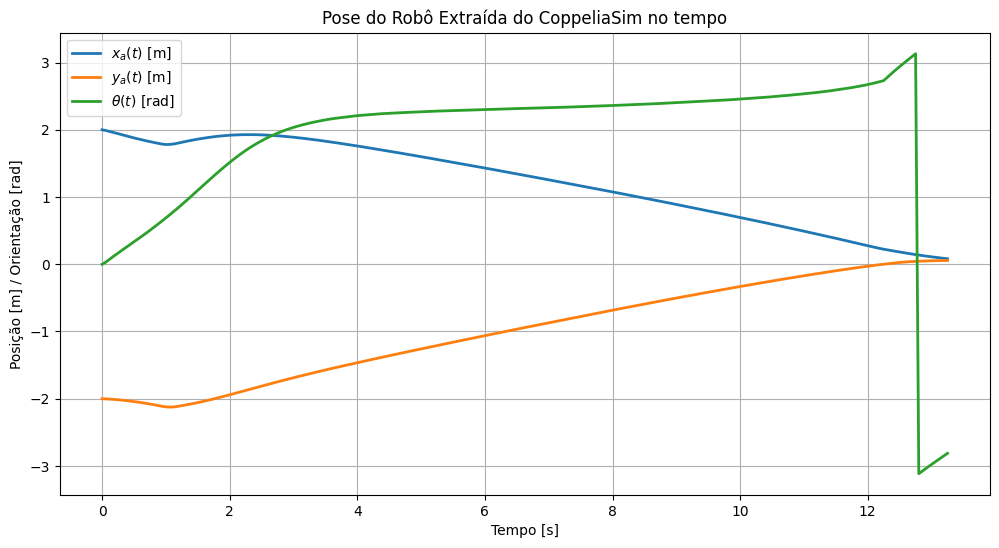

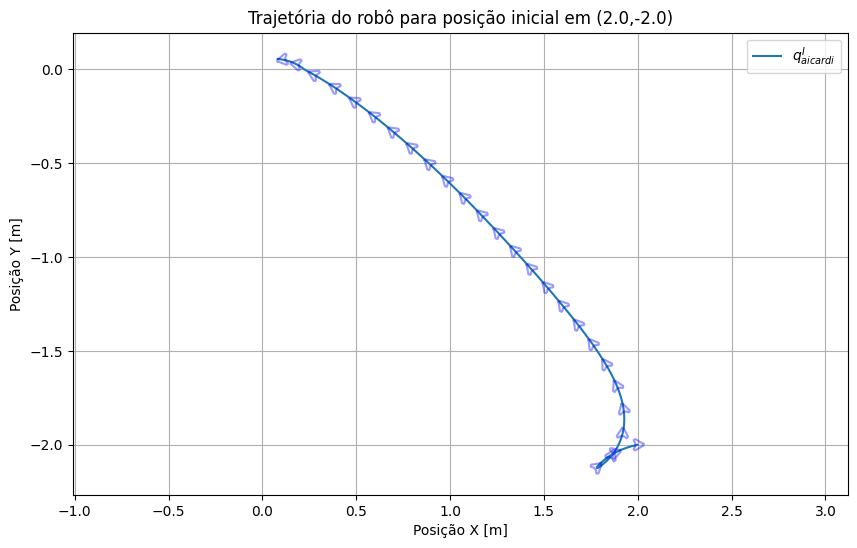

In [137]:
time_a = np.array(time_history_a)
aicardi_robot_pose = np.array(aicardi_robot_pose_history)

np.save(f"trajetoria_aicardi_{i}.npy", aicardi_robot_pose)

pose_no_tempo(time_a,aicardi_robot_pose[:,0], aicardi_robot_pose[:,1], aicardi_robot_pose[:,2])

# P Plot robot pose in X and Y
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(aicardi_robot_pose[:,0], aicardi_robot_pose[:,1], label='$q^I_{aicardi}$', lw=1.5)
scale = 0.03 
step = 10

for i in range(0, len(time_a)-1, step):
    draw_robot(aicardi_robot_pose[i,0], aicardi_robot_pose[i,1], aicardi_robot_pose[i,2], ax, scale=scale, color='blue', alpha=0.4)

ax.set_title(f'Trajetória do robô para posição inicial em ({aicardi_robot_pose[0,0]:.2},{aicardi_robot_pose[0,1]:.2})')
ax.set_xlabel('Posição X [m]')
ax.set_ylabel('Posição Y [m]')
ax.axis('equal')
ax.grid(True)
ax.legend()
plt.show()

## Simulation Loop - Benbouabdallah

In [138]:
# Initialize the Remote API
client = RemoteAPIClient()
sim = client.require('sim')

# Use the stepping mode
sim.setStepping(True)   

# Configure the handles
Turtlebot3 = sim.getObjectHandle('/Turtlebot3')
leftMotor = sim.getObjectHandle('/Turtlebot3/left_motor')
rightMotor = sim.getObjectHandle('/Turtlebot3/right_motor')
Goal = sim.getObjectHandle('/ReferenceFrame')

# Initialize the simulation
sim.startSimulation()

# Control gains
Kv = 2.07
Kw = 1.49
Dd = 0.1

time_history_b = []
benbolada_robot_pose_history = []

while True:

    # Capture the robot pose from simulation
    TBPos=sim.getObjectPosition(Turtlebot3,-1)
    TBXOri=sim.getObjectOrientation(Turtlebot3,-1)
    qTurtlebot = np.array([TBPos[0], TBPos[1], TBXOri[2]])

    # Capture the goal pose
    Goal_Pos = sim.getObjectPosition(Goal,-1)
    Goal_Ori = sim.getObjectOrientation(Goal,-1)
    qGoal = np.array([Goal_Pos[0], Goal_Pos[1],Goal_Ori[2]])

    time_history_b.append(sim.getSimulationTime())
    benbolada_robot_pose_history.append(qTurtlebot)

    # Global States
    dx, dy, dth = qGoal - qTurtlebot
    # Transform to Benbouabdallah states
    D = math.sqrt(dx**2 + dy**2)
    alpha = normalize_angle(-np.arctan2(dy,dx) + qTurtlebot[2])
    theta_aicardi = normalize_angle(qGoal[2] - np.arctan2(dy,dx))
    ed = -Dd + D

    # Stopping condition
    if D < Dd:
        # Goal achieved
        print("Alvo alcançado!")
        sim.stopSimulation()
        break

    # Calculate linear and angular velocities from (14)
    # v_tt = -Kv * ed * math.cos(alpha)
    v_tt = Kv * ed * math.cos(alpha)
    
    # omega = k*alpha + gamma * (cos(alpha)*sin(alpha)/alpha) * (alpha + h*theta)
    omega_tt = -Kw * alpha - (v_tt/D) * math.sin(alpha)

    # Saturation Limits
    v_tt = max(min(v_tt, maxv), -maxv)
    omega_tt = max(min(omega_tt, maxw), -maxw) 


    #  DDMR Inverse Kinematics
    w_right = (v_tt + (omega_tt * robot_width / 2)) / wheel_radius
    w_left  = (v_tt - (omega_tt * robot_width / 2)) / wheel_radius

    # Send commands
    sim.setJointTargetVelocity(leftMotor, w_left)
    sim.setJointTargetVelocity(rightMotor, w_right)

    # print(f"Erro: {D} | Alpha: {alpha} | Theta: {theta_aicardi}")
    # print(f"v: {v_tt}, omega: {omega_tt}\n")
    # Step the simulation
    sim.step()

Alvo alcançado!


### Plot the results for the Benbouabdallah

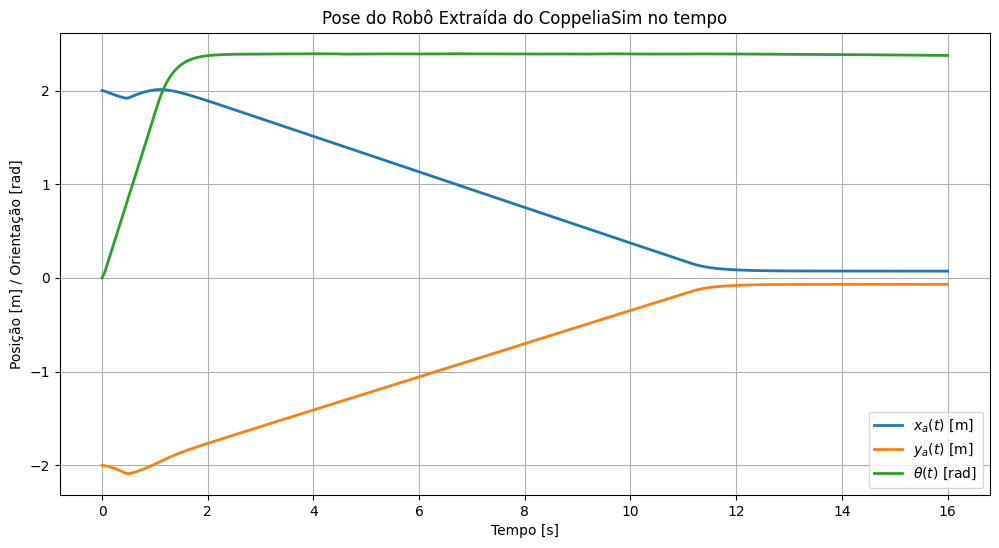

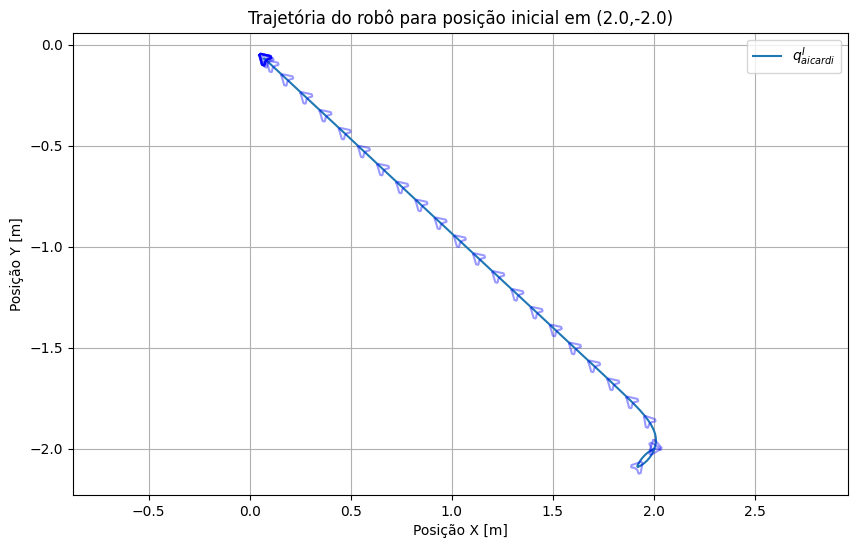

In [139]:
time_b = np.array(time_history_b)
benbolada_robot_pose = np.array(benbolada_robot_pose_history)

np.save(f"trajetoria_benbolada_{i}.npy", benbolada_robot_pose)

pose_no_tempo(time_b,benbolada_robot_pose[:,0], benbolada_robot_pose[:,1], benbolada_robot_pose[:,2])

# P Plot robot pose in X and Y
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(benbolada_robot_pose[:,0], benbolada_robot_pose[:,1], label='$q^I_{aicardi}$', lw=1.5)
scale = 0.03 
step = 10

for i in range(0, len(time_b)-1, step):
    draw_robot(benbolada_robot_pose[i,0], benbolada_robot_pose[i,1], benbolada_robot_pose[i,2], ax, scale=scale, color='blue', alpha=0.4)

ax.set_title(f'Trajetória do robô para posição inicial em ({benbolada_robot_pose[0,0]:.2},{benbolada_robot_pose[0,1]:.2})')
ax.set_xlabel('Posição X [m]')
ax.set_ylabel('Posição Y [m]')
ax.axis('equal')
ax.grid(True)
ax.legend()
plt.show()

## Plot all the trajectorys

/tmp/ipykernel_5502/348339467.py:147: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


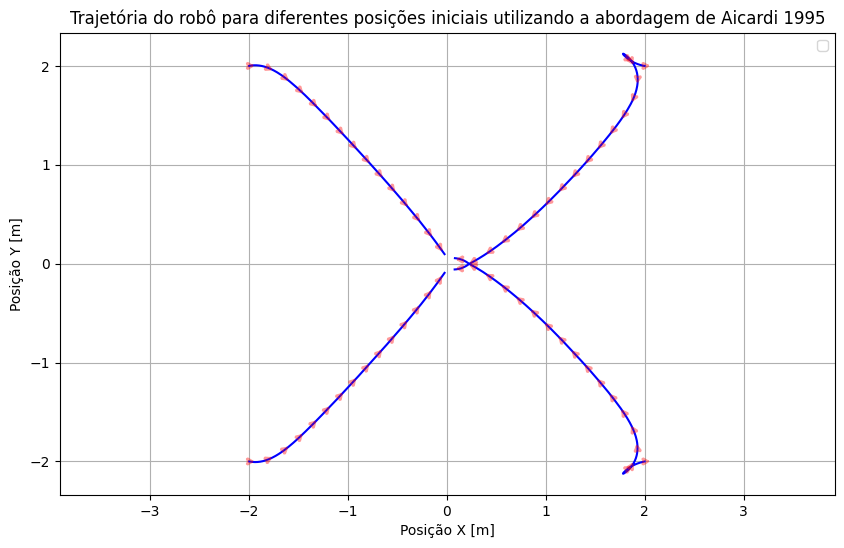

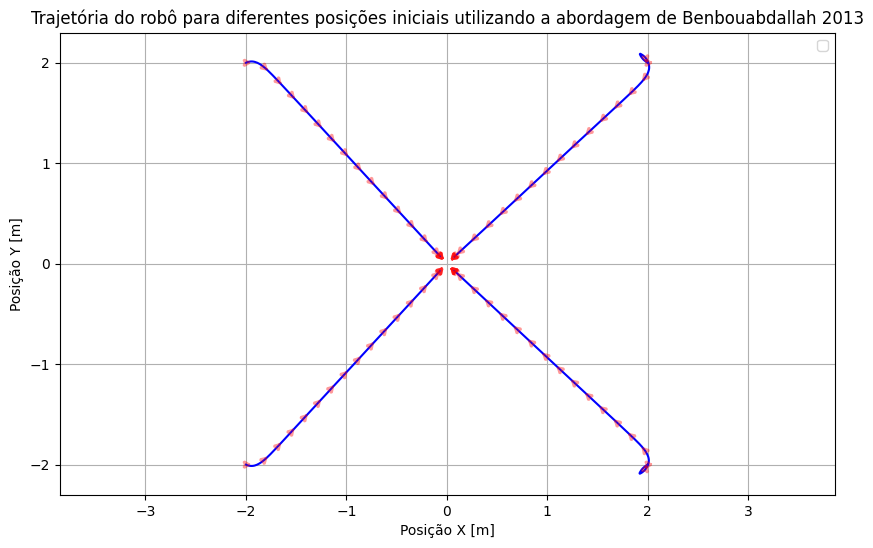

Para square_pose/data_aicardi/trajetoria_aicardi_3.npy, comprimento de 2.8
Para square_pose/data_aicardi/trajetoria_aicardi_4.npy, comprimento de 3.3
Para square_pose/data_aicardi/trajetoria_aicardi_1.npy, comprimento de 3.3
Para square_pose/data_aicardi/trajetoria_aicardi_2.npy, comprimento de 2.8
Comprimento médio de caminho igual a 3.1 para abordagem de Aicardi 1995
Para square_pose/data_benbouabdallah/trajetoria_benbolada_3.npy, comprimento de 2.8
Para square_pose/data_benbouabdallah/trajetoria_benbolada_4.npy, comprimento de 3.0
Para square_pose/data_benbouabdallah/trajetoria_benbolada_1.npy, comprimento de 3.0
Para square_pose/data_benbouabdallah/trajetoria_benbolada_2.npy, comprimento de 2.8
Comprimento médio de caminho igual a 2.9 para abordagem de Benbouabdallah 2013


In [149]:
plot_all_trajectorys(data_dir="square_pose/data_aicardi", algorithm='Aicardi 1995')

plot_all_trajectorys(data_dir="square_pose/data_benbouabdallah", algorithm='Benbouabdallah 2013')

compute_mean_path(data_dir="square_pose/data_aicardi", algorithm='Aicardi 1995')

compute_mean_path(data_dir="square_pose/data_benbouabdallah", algorithm='Benbouabdallah 2013')

In [155]:
aicardi_robot_pose.shape

(266, 3)